# Spectral / Fourier Features — Mitt

**THIS NOTEBOOK IMPLEMENTS THE SPECTRAL/FOURIER FEATURE APPROACH FROM THE MEETING NOTES.**

**To be explicit: this notebook trains a real, working supervised machine learning model** (logistic
regression, a GLM, same model family as notebook 03), it is not just signal-processing/analysis code.
Fourier/spectral analysis here is the FEATURE ENGINEERING step, turning raw voltage into frequency-band
power numbers, the model itself is what's trained and evaluated afterward on those features, with real
train/test splits, real predictions, and real accuracy metrics. See Section 7, "Model Performance
Summary," for a single place that shows exactly what this model achieved.

So far, every model (GLM in notebook 03, RNN in notebook 04) has used raw voltage: either summary stats
(mean/std) or the full raw time series. Neither of those directly represents *oscillatory* structure,
the rhythmic brain waves (like theta, ~4-8 Hz) we saw by eye in the very first LFP plot back in
notebook 01. This notebook builds a different feature representation: instead of "what was the voltage
doing," it asks "how much energy was present at each frequency," which is a much more direct match to
what the meeting notes flagged as neuroscientifically meaningful.

**What is a Fourier transform, in plain terms?** Any signal, no matter how complicated it looks, can be
broken down into a sum of simple sine waves at different frequencies and amplitudes (this is the
mathematical idea "Ferria transform" in the notes was referring to, the Fourier transform). Running an
FFT (Fast Fourier Transform) on a chunk of LFP tells us, for each frequency, how much that frequency
contributed to the signal, its "power." Grouping those frequencies into standard neuroscience bands
(theta, alpha, etc.) gives us a small, interpretable, biologically meaningful feature per channel,
instead of a raw, hard-to-interpret voltage trace.

**Goal of this notebook:** build spectral (frequency-band power) features from the same trial windows
used before, train the same GLM approach as notebook 03 on these new features instead of raw mean/std,
and compare directly against both the raw-feature GLM and the target benchmarks from the meeting notes
(beat chance, then aim toward ~85% for InSeq/OutSeq). We still want the best accuracy we can get,
spectral features are being tried specifically because they might do better, not as a detour from that
goal.


In [39]:
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, accuracy_score, confusion_matrix

from src.preprocessing import build_labels, segment_trials, get_sampling_rate


## 1. Load data, labels, and windows

Identical to notebook 03: same session (Mitt), same 500ms forward-extending windows. Only the feature
extraction step (Section 3 below) is new.


In [40]:
session_dir = '../data/raw/080718_mitt'
session_name = '080718_mitt'

bvr = np.load(f'{session_dir}/{session_name}_bvr.npz', allow_pickle=True)
bvr_data = bvr['data']
bvr_keys = bvr['keys'].tolist()

lfp = np.load(f'{session_dir}/{session_name}_lfp.npz', allow_pickle=True)
lfp_data = lfp['data']
lfp_keys = lfp['keys'].tolist()

fs = get_sampling_rate(bvr_data, bvr_keys)
print(f"Sampling rate: {fs:.2f} Hz")

labels = build_labels(bvr_data, bvr_keys)

WINDOW_MS = 500
windows, kept_idx = segment_trials(lfp_data, labels['trial_idx'], WINDOW_MS, fs)

kept_mask = np.isin(labels['trial_idx'], kept_idx)
inseq_outseq = labels['inseq_outseq'][kept_mask]
odor_id = labels['odor_id'][kept_mask]

print("windows shape:", windows.shape, "-> (n_trials, n_channels, window_samples)")


Sampling rate: 714.05 Hz
windows shape: (292, 22, 357) -> (n_trials, n_channels, window_samples)


## 2. Look at one example spectrum first

Before building features for every trial, let's look at a single example to confirm the FFT is doing
what we expect: showing a peak of power somewhere in the theta range (4-8 Hz), matching the oscillation
we saw visually in notebook 01.

We compute the power spectrum using `np.fft.rfft` (the "real FFT," appropriate since our LFP signal is
real-valued, not complex), then convert to power (magnitude squared) and get the matching frequency
axis with `np.fft.rfftfreq`.


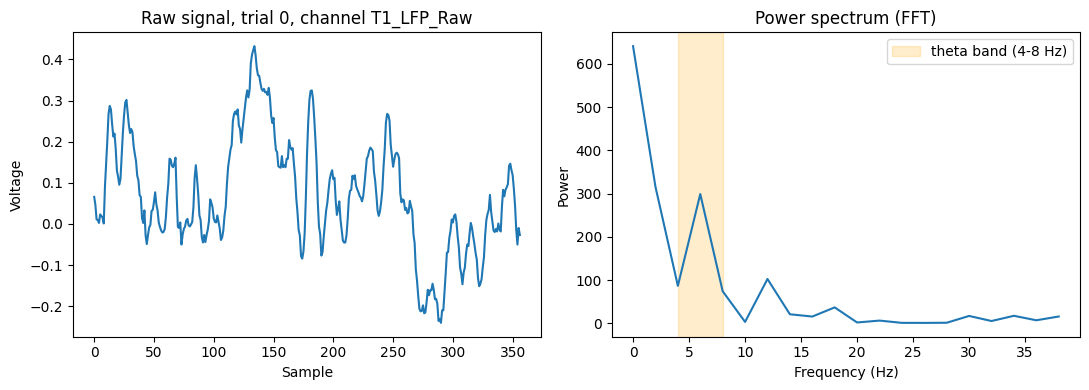

In [41]:
example_trial = 0
example_channel = 0

signal = windows[example_trial, example_channel, :]
n_samples = len(signal)

fft_vals = np.fft.rfft(signal)
power = np.abs(fft_vals) ** 2
freqs = np.fft.rfftfreq(n_samples, d=1 / fs)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(signal)
axes[0].set_title(f'Raw signal, trial {example_trial}, channel {lfp_keys[example_channel]}')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('Voltage')

# only plot up to 40 Hz, that's where nearly all the meaningful LFP power lives
freq_mask = freqs <= 40
axes[1].plot(freqs[freq_mask], power[freq_mask])
axes[1].axvspan(4, 8, color='orange', alpha=0.2, label='theta band (4-8 Hz)')
axes[1].set_title('Power spectrum (FFT)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power')
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Build spectral features for every trial

Standard neuroscience frequency bands (adjust boundaries later if the paper defines them differently):

| Band | Range (Hz) | Associated with |
|---|---|---|
| Delta | 1-4 | slow-wave states |
| Theta | 4-8 | active behavior, memory, navigation, the one the meeting notes flagged specifically |
| Alpha | 8-12 | attention, sensory gating |
| Beta | 12-30 | motor activity, alertness |
| Low gamma | 30-80 | local circuit processing |

For each trial and each channel, we compute total power within each band. Result: 22 channels x 5 bands
= 110 features per trial, replacing the 44 mean/std features from notebook 03.


In [42]:
BANDS = {
    'delta': (1, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'low_gamma': (30, 80),
}

def extract_spectral_features(windows, fs, bands):
    n_trials, n_channels, n_samples = windows.shape
    freqs = np.fft.rfftfreq(n_samples, d=1 / fs)

    band_masks = {name: (freqs >= lo) & (freqs < hi) for name, (lo, hi) in bands.items()}

    n_features = n_channels * len(bands)
    X = np.zeros((n_trials, n_features), dtype=np.float64)
    feature_names = []

    col = 0
    for ch in range(n_channels):
        fft_vals = np.fft.rfft(windows[:, ch, :], axis=1)  # (n_trials, n_freqs)
        power = np.abs(fft_vals) ** 2
        for band_name, mask in band_masks.items():
            X[:, col] = power[:, mask].sum(axis=1)
            feature_names.append(f"ch{ch}_{band_name}")
            col += 1

    return X, feature_names

X_spectral, spectral_feature_names = extract_spectral_features(windows, fs, BANDS)
print("Spectral feature matrix shape:", X_spectral.shape)

# power values span a huge range, log-transform to make them better behaved for a linear model
X_spectral_log = np.log1p(X_spectral)


Spectral feature matrix shape: (292, 110)


## 4. Task 1: InSeq vs OutSeq, using spectral features

Exact same evaluation setup as notebook 03 (logistic regression, standardized, 5-fold stratified
cross-validation, `class_weight='balanced'`), so the ONLY thing that changed is the feature set. That
makes this a clean, direct comparison.


In [43]:
y_inseq = inseq_outseq

pipe_inseq_spec = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_bal_acc_spec = cross_val_score(pipe_inseq_spec, X_spectral_log, y_inseq, cv=skf, scoring='balanced_accuracy')
fold_acc_spec = cross_val_score(pipe_inseq_spec, X_spectral_log, y_inseq, cv=skf, scoring='accuracy')

for fold in range(5):
    print(f"Fold {fold}: accuracy={fold_acc_spec[fold]:.3f}  balanced_accuracy={fold_bal_acc_spec[fold]:.3f}")

print()
print(f"Mean accuracy: {fold_acc_spec.mean():.3f}")
print(f"Mean balanced accuracy: {fold_bal_acc_spec.mean():.3f} +/- {fold_bal_acc_spec.std():.3f}  (chance = 0.500)")
print(f"\nFor comparison, notebook 03 (raw mean/std features): mean balanced accuracy ~0.559")


Fold 0: accuracy=0.763  balanced_accuracy=0.425
Fold 1: accuracy=0.881  balanced_accuracy=0.712
Fold 2: accuracy=0.741  balanced_accuracy=0.561
Fold 3: accuracy=0.810  balanced_accuracy=0.673
Fold 4: accuracy=0.793  balanced_accuracy=0.590

Mean accuracy: 0.798
Mean balanced accuracy: 0.592 +/- 0.100  (chance = 0.500)

For comparison, notebook 03 (raw mean/std features): mean balanced accuracy ~0.559


### Confusion matrix and band importance


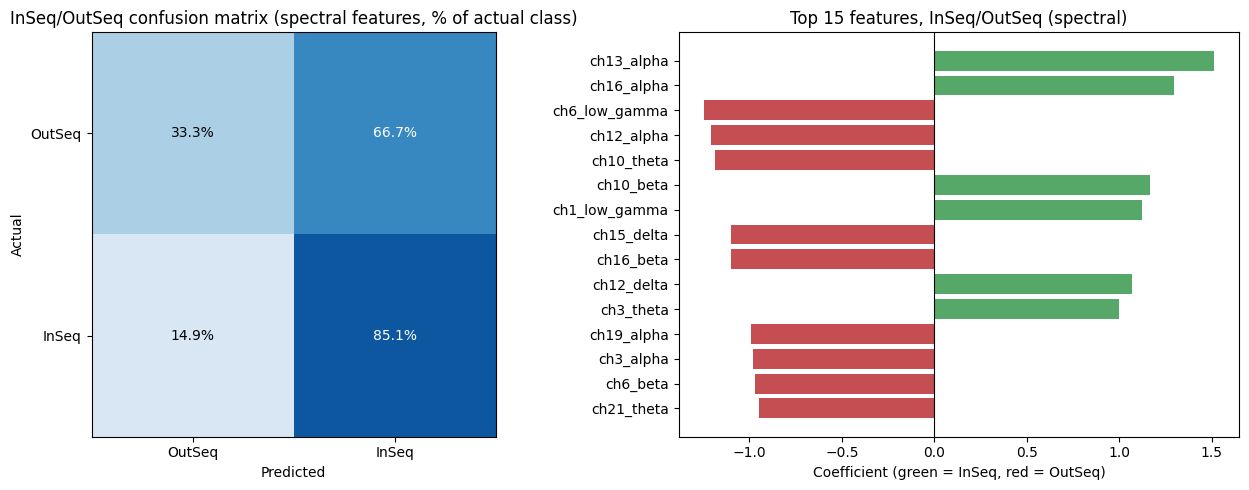

In [44]:
preds_inseq_spec = cross_val_predict(pipe_inseq_spec, X_spectral_log, y_inseq, cv=skf)
cm_spec = confusion_matrix(y_inseq, preds_inseq_spec)

# row-normalize to percentages: each row = recall breakdown for that true class, sums to 100%
cm_spec_pct = cm_spec.astype(float) / cm_spec.sum(axis=1, keepdims=True) * 100

pipe_inseq_spec.fit(X_spectral_log, y_inseq)
coefs_spec = pipe_inseq_spec.named_steps['clf'].coef_[0]
order = np.argsort(np.abs(coefs_spec))[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(cm_spec_pct, cmap='Blues', vmin=0, vmax=100)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['OutSeq', 'InSeq'])
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(['OutSeq', 'InSeq'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('InSeq/OutSeq confusion matrix (spectral features, % of actual class)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm_spec_pct[i, j]:.1f}%', ha='center', va='center',
                      color='white' if cm_spec_pct[i, j] > 50 else 'black')

colors = ['#C44E52' if coefs_spec[i] < 0 else '#55A868' for i in order]
axes[1].barh(range(len(order)), coefs_spec[order], color=colors)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels([spectral_feature_names[i] for i in order])
axes[1].invert_yaxis()
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient (green = InSeq, red = OutSeq)')
axes[1].set_title('Top 15 features, InSeq/OutSeq (spectral)')

plt.tight_layout()
plt.show()


## 5. Task 2: Odor identity, InSeq trials only, using spectral features

Same restriction as before: odor classification only evaluated on InSeq trials, per the meeting notes.


In [45]:
inseq_mask = (y_inseq == 1)
X_odor_spec = X_spectral_log[inseq_mask]
y_odor = odor_id[inseq_mask]

pipe_odor_spec = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced')),
])

skf_odor = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_bal_acc_odor_spec = cross_val_score(pipe_odor_spec, X_odor_spec, y_odor, cv=skf_odor, scoring='balanced_accuracy')
fold_acc_odor_spec = cross_val_score(pipe_odor_spec, X_odor_spec, y_odor, cv=skf_odor, scoring='accuracy')

for fold in range(5):
    print(f"Fold {fold}: accuracy={fold_acc_odor_spec[fold]:.3f}  balanced_accuracy={fold_bal_acc_odor_spec[fold]:.3f}")

print()
print(f"Mean accuracy: {fold_acc_odor_spec.mean():.3f}")
print(f"Mean balanced accuracy: {fold_bal_acc_odor_spec.mean():.3f} +/- {fold_bal_acc_odor_spec.std():.3f}  (chance = 0.200)")
print(f"\nFor comparison, notebook 03 (raw mean/std features): mean balanced accuracy ~0.346")


Fold 0: accuracy=0.340  balanced_accuracy=0.335
Fold 1: accuracy=0.245  balanced_accuracy=0.239
Fold 2: accuracy=0.442  balanced_accuracy=0.372
Fold 3: accuracy=0.250  balanced_accuracy=0.242
Fold 4: accuracy=0.365  balanced_accuracy=0.338

Mean accuracy: 0.329
Mean balanced accuracy: 0.305 +/- 0.055  (chance = 0.200)

For comparison, notebook 03 (raw mean/std features): mean balanced accuracy ~0.346


### Confusion matrix and band importance


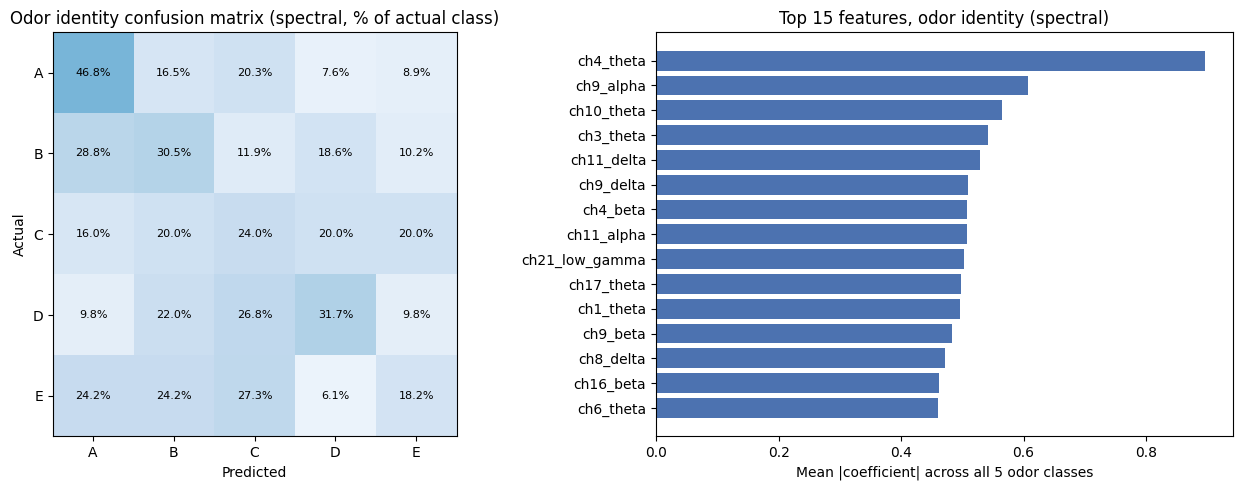

In [46]:
preds_odor_spec = cross_val_predict(pipe_odor_spec, X_odor_spec, y_odor, cv=skf_odor)
cm_odor_spec = confusion_matrix(y_odor, preds_odor_spec)
odor_labels = ['A', 'B', 'C', 'D', 'E']

# row-normalize to percentages: each row = recall breakdown for that true odor, sums to 100%
cm_odor_spec_pct = cm_odor_spec.astype(float) / cm_odor_spec.sum(axis=1, keepdims=True) * 100

pipe_odor_spec.fit(X_odor_spec, y_odor)
coefs_odor_spec = pipe_odor_spec.named_steps['clf'].coef_
importance_spec = np.abs(coefs_odor_spec).mean(axis=0)
order_odor = np.argsort(importance_spec)[::-1][:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].imshow(cm_odor_spec_pct, cmap='Blues', vmin=0, vmax=100)
axes[0].set_xticks(range(5)); axes[0].set_xticklabels(odor_labels)
axes[0].set_yticks(range(5)); axes[0].set_yticklabels(odor_labels)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Odor identity confusion matrix (spectral, % of actual class)')
for i in range(5):
    for j in range(5):
        axes[0].text(j, i, f'{cm_odor_spec_pct[i, j]:.1f}%', ha='center', va='center',
                      color='white' if cm_odor_spec_pct[i, j] > 50 else 'black', fontsize=8)

axes[1].barh(range(len(order_odor)), importance_spec[order_odor], color='#4C72B0')
axes[1].set_yticks(range(len(order_odor)))
axes[1].set_yticklabels([spectral_feature_names[i] for i in order_odor])
axes[1].invert_yaxis()
axes[1].set_xlabel('Mean |coefficient| across all 5 odor classes')
axes[1].set_title('Top 15 features, odor identity (spectral)')

plt.tight_layout()
plt.show()


## 7. Model Performance Summary — is this hitting our goals?

This is the single place to look for "did the model work, and is it good enough." Compares this
spectral-feature model against: chance level, the raw-feature GLM from notebook 03, and the ~85%
InSeq/OutSeq target mentioned in the meeting notes (odor identity has no specific numeric target, just
"should be easier than InSeq/OutSeq").


In [47]:
print("=" * 70)
print("MODEL PERFORMANCE SUMMARY")
print("Model: Logistic Regression (GLM) trained on spectral (FFT band power) features")
print("=" * 70)

print(f"\n{'InSeq/OutSeq Task':30s}")
print(f"{'  Chance level:':30s} 50.0%")
print(f"{'  Raw mean/std GLM (nb 03):':30s} {0.559*100:.1f}%")
print(f"{'  Spectral GLM (this model):':30s} {fold_bal_acc_spec.mean()*100:.1f}%  (+/- {fold_bal_acc_spec.std()*100:.1f}%)")
print(f"{'  Meeting target:':30s} ~85.0%")
gap_to_target = 85 - fold_bal_acc_spec.mean() * 100
print(f"{'  Gap to target:':30s} {gap_to_target:.1f} percentage points short")
status_inseq = "BEATS CHANCE" if fold_bal_acc_spec.mean() > 0.5 else "AT OR BELOW CHANCE"
print(f"{'  Status:':30s} {status_inseq}, but well short of the ~85% target")

print(f"\n{'Odor Identity Task':30s}")
print(f"{'  Chance level:':30s} 20.0%")
print(f"{'  Raw mean/std GLM (nb 03):':30s} {0.346*100:.1f}%")
print(f"{'  Spectral GLM (this model):':30s} {fold_bal_acc_odor_spec.mean()*100:.1f}%  (+/- {fold_bal_acc_odor_spec.std()*100:.1f}%)")
print(f"{'  Meeting target:':30s} no specific number, described as 'easier'")
status_odor = "BEATS CHANCE" if fold_bal_acc_odor_spec.mean() > 0.2 else "AT OR BELOW CHANCE"
print(f"{'  Status:':30s} {status_odor}")

print("\n" + "=" * 70)
print("BOTTOM LINE")
print("=" * 70)
print("Both tasks beat chance, confirming there IS real, learnable signal in the")
print("spectral features. Neither task is close to the ~85% target yet. This is")
print("expected at this stage, single rat, single simple linear model, no")
print("cross-rat pooling, no hyperparameter tuning yet. Treat this as a")
print("confirmed-working, beats-chance baseline, not a finished result.")


MODEL PERFORMANCE SUMMARY
Model: Logistic Regression (GLM) trained on spectral (FFT band power) features

InSeq/OutSeq Task             
  Chance level:                50.0%
  Raw mean/std GLM (nb 03):    55.9%
  Spectral GLM (this model):   59.2%  (+/- 10.0%)
  Meeting target:              ~85.0%
  Gap to target:               25.8 percentage points short
  Status:                      BEATS CHANCE, but well short of the ~85% target

Odor Identity Task            
  Chance level:                20.0%
  Raw mean/std GLM (nb 03):    34.6%
  Spectral GLM (this model):   30.5%  (+/- 5.5%)
  Meeting target:              no specific number, described as 'easier'
  Status:                      BEATS CHANCE

BOTTOM LINE
Both tasks beat chance, confirming there IS real, learnable signal in the
spectral features. Neither task is close to the ~85% target yet. This is
expected at this stage, single rat, single simple linear model, no
cross-rat pooling, no hyperparameter tuning yet. Treat this as 

## 8. Text-only results summary

Same pattern as notebooks 03 and 04, for easy copy/paste sharing without images. Includes confusion
matrices both as raw counts and as row-normalized percentages (each row sums to 100%, so each row shows
what percent of that true class got predicted as each possible class, i.e. a recall breakdown), so
results can be read and interpreted directly from text, no screenshots needed.


In [48]:
import json as _json
import os

def cm_to_percent(cm):
    """Row-normalize a confusion matrix to percentages (each row = recall breakdown for that true class)."""
    cm = np.array(cm, dtype=float)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1  # avoid divide-by-zero
    return np.round(100 * cm / row_sums, 1)

cm_spec_pct = cm_to_percent(cm_spec)
cm_odor_spec_pct = cm_to_percent(cm_odor_spec)

results_summary = {
    "session": session_name,
    "feature_type": "spectral (FFT band power: delta, theta, alpha, beta, low_gamma)",
    "n_features": X_spectral.shape[1],
    "inseq_outseq_task": {
        "fold_accuracy": [round(float(v), 4) for v in fold_acc_spec],
        "fold_balanced_accuracy": [round(float(v), 4) for v in fold_bal_acc_spec],
        "mean_accuracy": round(float(fold_acc_spec.mean()), 4),
        "mean_balanced_accuracy": round(float(fold_bal_acc_spec.mean()), 4),
        "std_balanced_accuracy": round(float(fold_bal_acc_spec.std()), 4),
        "confusion_matrix_counts": {"labels": ["OutSeq", "InSeq"], "matrix": cm_spec.tolist()},
        "confusion_matrix_percent": {
            "labels": ["OutSeq", "InSeq"],
            "note": "each row sums to 100%, i.e. row = recall breakdown for that true class",
            "matrix": cm_spec_pct.tolist(),
        },
        "top_features": [
            {"feature": spectral_feature_names[i], "coefficient": round(float(coefs_spec[i]), 4)}
            for i in order
        ],
        "comparison_to_raw_mean_std_features": 0.559,
    },
    "odor_task": {
        "fold_accuracy": [round(float(v), 4) for v in fold_acc_odor_spec],
        "fold_balanced_accuracy": [round(float(v), 4) for v in fold_bal_acc_odor_spec],
        "mean_accuracy": round(float(fold_acc_odor_spec.mean()), 4),
        "mean_balanced_accuracy": round(float(fold_bal_acc_odor_spec.mean()), 4),
        "std_balanced_accuracy": round(float(fold_bal_acc_odor_spec.std()), 4),
        "confusion_matrix_counts": {"labels": odor_labels, "matrix": cm_odor_spec.tolist()},
        "confusion_matrix_percent": {
            "labels": odor_labels,
            "note": "each row sums to 100%, i.e. row = recall breakdown for that true class",
            "matrix": cm_odor_spec_pct.tolist(),
        },
        "top_features": [
            {"feature": spectral_feature_names[i], "mean_abs_coefficient": round(float(importance_spec[i]), 4)}
            for i in order_odor
        ],
        "comparison_to_raw_mean_std_features": 0.346,
    },
}

print(_json.dumps(results_summary, indent=2))

os.makedirs('../outputs/logs', exist_ok=True)
with open('../outputs/logs/spectral_baseline_results.json', 'w') as f:
    _json.dump(results_summary, f, indent=2)
print("\nSaved to outputs/logs/spectral_baseline_results.json")


{
  "session": "080718_mitt",
  "feature_type": "spectral (FFT band power: delta, theta, alpha, beta, low_gamma)",
  "n_features": 110,
  "inseq_outseq_task": {
    "fold_accuracy": [
      0.7627,
      0.8814,
      0.7414,
      0.8103,
      0.7931
    ],
    "fold_balanced_accuracy": [
      0.4245,
      0.7123,
      0.5609,
      0.6731,
      0.5897
    ],
    "mean_accuracy": 0.7978,
    "mean_balanced_accuracy": 0.5921,
    "std_balanced_accuracy": 0.1001,
    "confusion_matrix_counts": {
      "labels": [
        "OutSeq",
        "InSeq"
      ],
      "matrix": [
        [
          10,
          20
        ],
        [
          39,
          223
        ]
      ]
    },
    "confusion_matrix_percent": {
      "labels": [
        "OutSeq",
        "InSeq"
      ],
      "note": "each row sums to 100%, i.e. row = recall breakdown for that true class",
      "matrix": [
        [
          33.3,
          66.7
        ],
        [
          14.9,
          85.1
        ]
 

## Spectral Features Results — Summary

### Model Performance vs. Benchmarks

| Task | Chance | Raw mean/std (nb 03) | Spectral (this model) | Target |
|---|---|---|---|---|
| InSeq/OutSeq | 50.0% | 55.9% | **59.2%** | ~85% |
| Odor identity | 20.0% | 34.6% | **30.5%** | "easier" (no set number) |

Both tasks beat chance, confirming real, learnable signal exists in the spectral features, this is a genuine, working model, not just analysis. But neither task is close to the ~85% target. InSeq/OutSeq is about 26 percentage points short.

### InSeq/OutSeq: spectral features helped
59.2% vs the raw-feature GLM's 55.9%, a real if modest improvement. Alpha and beta band power (from electrodes like ch13, ch16, ch12, ch10) were the most influential features, more than theta specifically for this task.

### Odor identity: spectral features hurt overall, but fixed a specific weak spot
30.5% vs the raw-feature GLM's 34.6%, a step backward on average. But per-class recall shows nuance: odor C, which scored *below chance* with raw features (14%), improved to 24% with spectral features. The cost was odors A and B, the raw model's strongest classes, both dropped. Theta band power dominated the important features here (ch4_theta was the single strongest predictor), more clearly than for the InSeq/OutSeq task.

### Final Thoughts
Spectral and raw voltage features appear to capture different, only partially overlapping information, neither is a strict upgrade over the other. Both are still well below where this needs to land.